## DAS-APL: Ejemplo de uso `das4whales`

In [24]:
import os
import sys
import numpy as np
import das4whales as dw
import scipy.signal as sp
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import pandas as pd
import matplotlib.patches as patches

#DAS_APL_NAS_SERVER_PATH = "Z:/DAS-APL"; sys.path.append(DAS_APL_NAS_SERVER_PATH)

#from tools.yolo4das.annotation import annotate

In [4]:
# The dataset of this example is constituted of 60s time series along  66 km of cable

# url = 'http://piweb.ooirsn.uw.edu/das/data/Optasense/NorthCable/TransmitFiber/' \
#       'North-C1-LR-P1kHz-GL50m-Sp2m-FS200Hz_2021-11-03T15_06_51-0700/'\
#       'North-C1-LR-P1kHz-GL50m-Sp2m-FS200Hz_2021-11-04T020002Z.h5'

# filepath, filename = dw.data_handle.dl_file(url)

In [9]:
# Read HDF5 files and access metadata
# Get the acquisition parameters for the data folder and store them in a dictionary

#filepath = 'Z:/DAS-APL/data/North-C1-LR-P1kHz-GL50m-Sp2m-FS200Hz_2021-11-04T020002Z.h5'
filepath = r"C:\Users\Santi\OneDrive - UPV\TFM - Santiago Campo Jurado\DAS\H5\North-C1-LR-P1kHz-GL50m-Sp2m-FS200Hz_2021-11-04T020002Z.h5"
metadata = dw.data_handle.get_acquisition_parameters(filepath, interrogator='optasense')

if True:
    fs = metadata['fs']                         # Sampling frequency [Hz]
    dx = metadata['dx']                         # Distance between channels [m]
    nx = metadata['nx']                         # Number of channels (channels)
    ns = metadata['ns']                         # Number of samples (time points)
    gauge_length = metadata['GL']               # Deformation integration length [m]
    scale_factor = metadata['scale_factor']     # Conversion to physical units (strain)

print(f'Sampling frequency: {metadata["fs"]} Hz')
print(f'Channel spacing: {metadata["dx"]} m')
print(f'Gauge length: {metadata["GL"]} m')
print(f'File duration: {metadata["ns"] / metadata["fs"]} s')
print(f'Cable max distance: {metadata["nx"] * metadata["dx"]/1e3:.1f} km')
print(f'Number of channels: {metadata["nx"]}')
print(f'Number of time samples: {metadata["ns"]}')

Sampling frequency: 200.0 Hz
Channel spacing: 2.0419046878814697 m
Gauge length: 51.0476188659668 m
File duration: 60.0 s
Cable max distance: 66.6 km
Number of channels: 32600
Number of time samples: 12000


In [ ]:
# List of values in meters corresponding to the starting ending and step wanted channels along the FO Cable
# selected_channels_m = [ChannelStart_m, ChannelStop_m, ChannelStep_m] in meters

CHANNEL_STRIDE = 1
selected_channels_m = [0, nx*dx, CHANNEL_STRIDE*dx] # (m)

# [ChannelStart, ChannelStop, ChannelStep]
selected_channels = [int(selected_channels_m // dx) for selected_channels_m in selected_channels_m] # idx

print('Begin channel: ', selected_channels[0])
print('End channel: ', selected_channels[1])
print('Step: ', selected_channels[2], '[', selected_channels[2] * dx, 'm ]')

Begin channel:  0
End channel:  32600
Step:  1 [ 2.0419047 m ]


In [11]:
# Load DAS data fro the example file: North-C1-LR-P1kHz-GL50m-Sp2m-FS200Hz_2021-11-04T020002Z.h5
# load_das_data() allow to load only the desired channels

tr, time, dist, fileBeginTimeUTC = dw.data_handle.load_das_data(filepath, selected_channels, metadata)
print('Shape: ', tr.shape)

Shape:  (32600, 12000)


In [12]:
# Band-pass filtering (10-30 Hz, ord. 5) and high-pass filtering (5 Hz, ord. 2)
# Fs: 200 Hz

sos_bpfilter = dw.dsp.butterworth_filter([5, [15, 25], 'bp'], fs)
sos_hpfilter = dw.dsp.butterworth_filter([2, 5, 'hp'], fs)

# Apply only B-P filter
trf = sp.sosfiltfilt(sos_bpfilter, tr, axis=1)

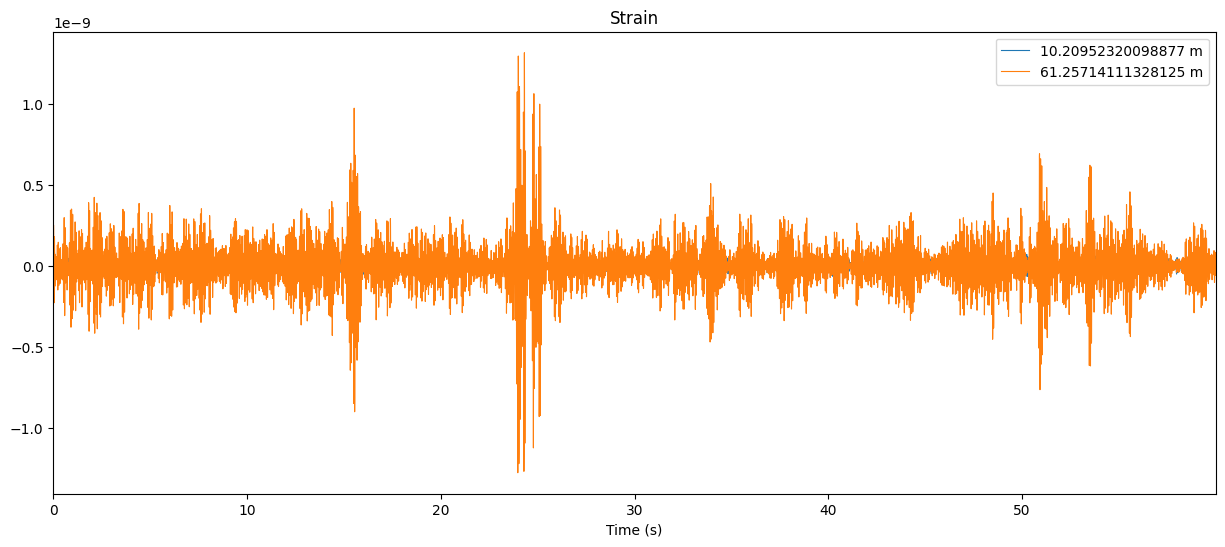

In [13]:
# Plot strain
points = [5, 30]
t = np.linspace(0, (ns - 1) / fs, num=nx)
data_to_plot = trf.copy()

%matplotlib inline
plt.figure(figsize=(15,6))
for point in points:
    plt.plot(time, data_to_plot[point, :], label=f'{point*dx} m', lw=0.8)
plt.title('Strain')
plt.xlabel('Time (s)')
plt.legend()
plt.xlim(np.min(t), np.max(t))
plt.show()

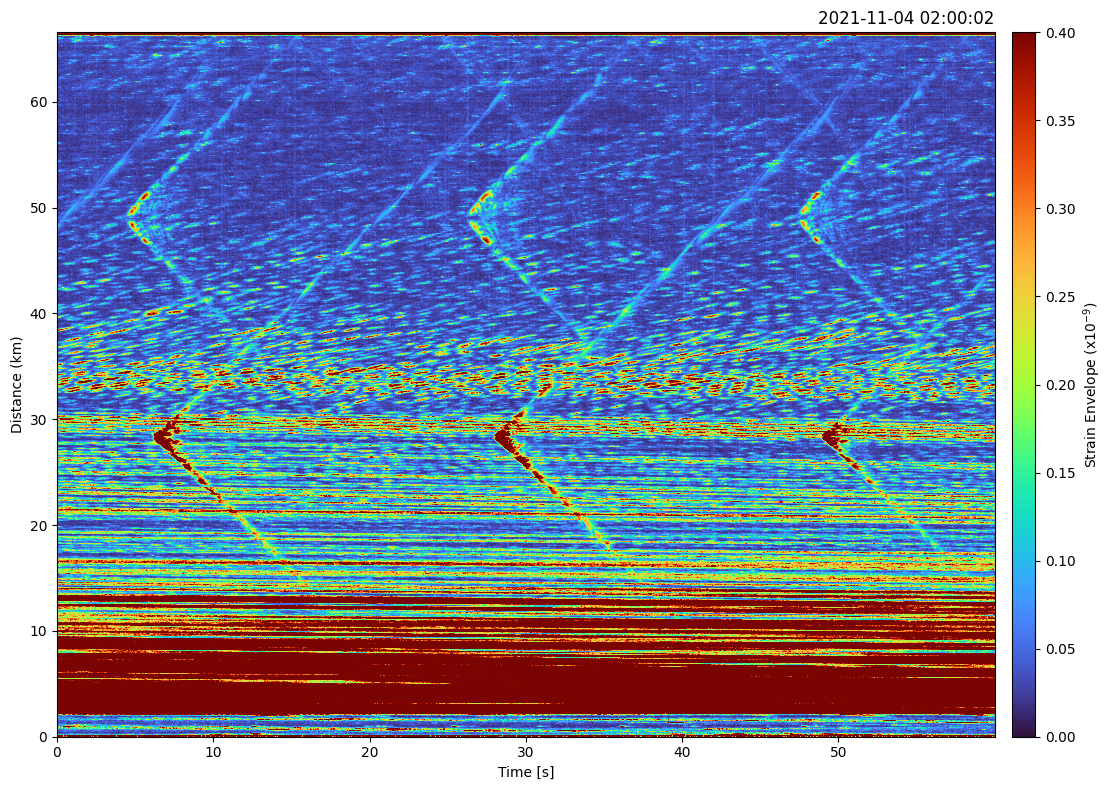

In [14]:
# TX plot (time x distance)

dw.plot.plot_tx(
    sp.hilbert(trf, axis=1), time, dist, fileBeginTimeUTC, 
    fig_size=(12, 8), v_min=0, v_max=0.4)

In [11]:
# Visualize and annotate the example data of the das4whales library using YOLO4DAS annotation tool
# We use the annotate() function which is agnostic to the data format

# import matplotlib; matplotlib.use("Qt5Agg")

# annotate(
#     tr=trf, 
#     dist_m=dist, time_s=time, 
#     fs_hz=fs, 
#     filename=filepath, 
#     vmin=0, vmax=0.4e-9,
#     start_datetime_utc=fileBeginTimeUTC,
#     save_dir=None,
#     save_directly=True,
#     annotations_output_format='csv',
#     data_output_format=None)

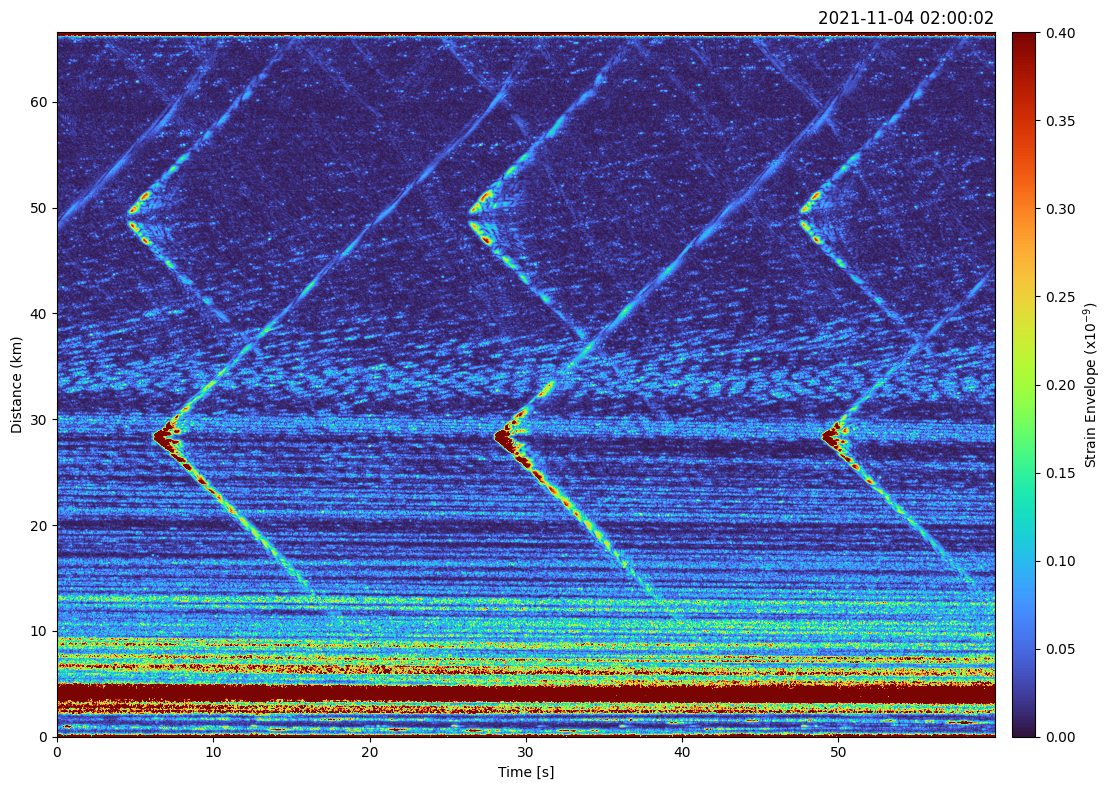

In [15]:
# Apply f-k (frequency-wavenumber) filtering and plot TX

fk_params_s = {
    'c_min': 1400.,     # m.s-1
    'c_max': 3500.,     # m.s-1
    'fmin': 10.,        # Hz
    'fmax': 30.         # Hz
}

fk_filter = dw.dsp.hybrid_ninf_gs_filter_design((tr.shape[0],tr.shape[1]), selected_channels, dx, fs, fk_params_s, display_filter=False)
trf_fk = dw.dsp.fk_filter_sparsefilt(trf, fk_filter, tapering=False)

dw.plot.plot_tx(sp.hilbert(trf_fk, axis=1), time, dist, fileBeginTimeUTC, fig_size=(12, 8), v_min=0, v_max=0.4)

   ID         t0         t1            d0            d1  ti0  ti1  di0  di1  \
0  HF   6.367947  28.364918  14931.001101  60730.508998    8   66    3  147   
1  HF   4.617381  12.589384  40001.585848  61866.164917    0   34   60  154   
2  HF  49.218723  58.644039  15458.879634  42402.638781  134  169    4   65   
3  HF  47.727028  56.008964  40980.150960  62710.271145  123  165   63  161   
4  HF  16.107607  21.537492  56072.075462  64688.550983   40   49  121  172   

    nx   nt  downsample          start_datetime_utc  comment  
0  180  180         NaN  2021-11-04T02:00:07.826780      NaN  
1  180  180         NaN  2021-11-04T02:00:06.076213      NaN  
2  180  180         NaN  2021-11-04T02:00:50.677556      NaN  
3  180  180         NaN  2021-11-04T02:00:49.185861      NaN  
4  180  180         NaN  2021-11-04T02:00:17.566439      NaN  


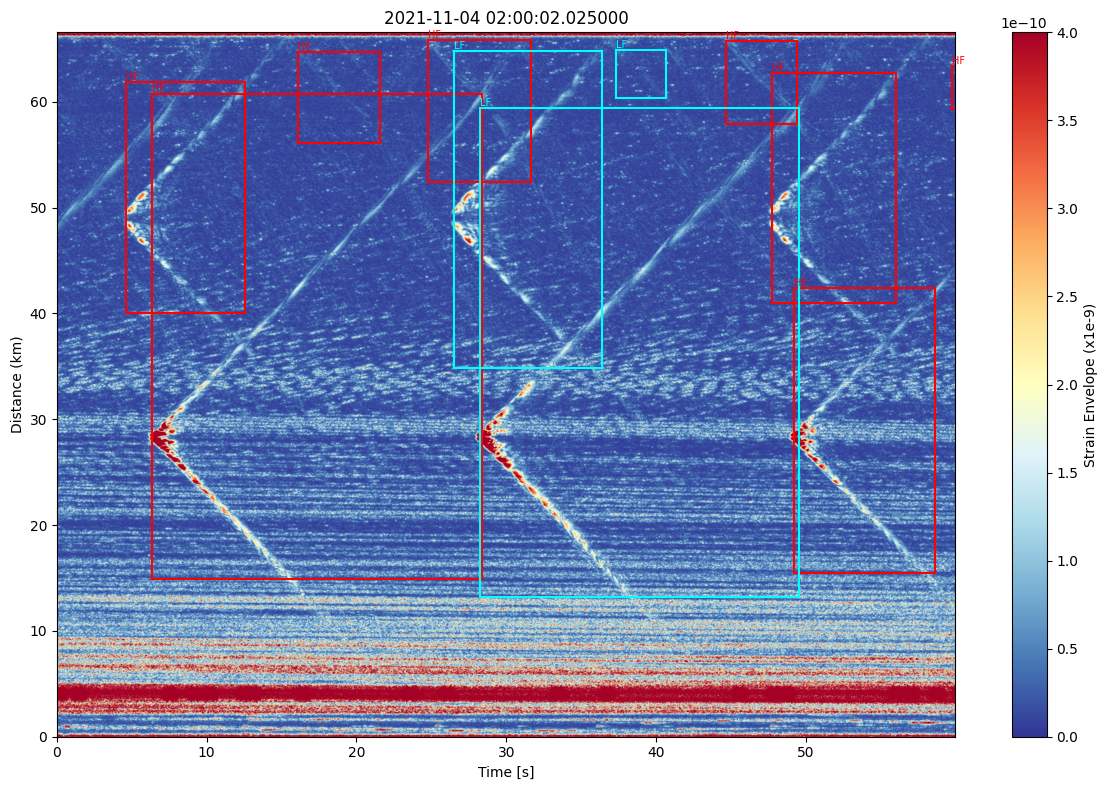

In [39]:
bbox_csv_path = r"C:\Users\Santi\OneDrive - UPV\TFM - Santiago Campo Jurado\DAS\D4W_bk\Batch1\renamed\North-C1-LR-P1kHz-GL50m-Sp2m-FS200Hz_2021-11-04T020002Z_bbox.csv"
df_bbox = pd.read_csv(bbox_csv_path)
print(df_bbox.head())

COLOR = {'HF': 'red', 'LF': 'cyan'}

def overlay_bboxes(ax, df_bbox):
    for _, row in df_bbox.iterrows():
        t0, t1 = row['t0'], row['t1']
        d0, d1 = row['d0'], row['d1']
        label  = row['ID']
        color  = COLOR.get(label, 'white')
        rect = patches.Rectangle(
            (t0, d0/1e3),        # dist in km (plot_tx uses km on y-axis)
            t1 - t0,
            (d1 - d0) / 1e3,
            linewidth=1.5,
            edgecolor=color,
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(t0, d1/1e3, label, color=color, fontsize=7, va='bottom')
        
        
fig, ax = plt.subplots(figsize=(12, 8))

# Downsample to reduce memory usage
stride_t = 4
stride_x = 4

envelope = np.abs(sp.hilbert(trf_fk, axis=1))
envelope_ds = envelope[::stride_x, ::stride_t]
time_ds = time[::stride_t]
dist_ds = dist[::stride_x]

ax.imshow(
    envelope_ds,
    aspect='auto',
    origin='lower',
    extent=[time_ds[0], time_ds[-1], dist_ds[0]/1e3, dist_ds[-1]/1e3],
    vmin=0, vmax=0.4e-9,
    cmap='RdYlBu_r'   # ← try this
)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Distance (km)')
ax.set_title(str(fileBeginTimeUTC))
plt.colorbar(ax.images[0], ax=ax, label='Strain Envelope (x1e-9)')

# Overlay bounding boxes
COLOR = {'HF': 'red', 'LF': 'cyan'}
for _, row in df_bbox.iterrows():
    t0, t1 = row['t0'], row['t1']
    d0, d1 = row['d0'] / 1e3, row['d1'] / 1e3
    label  = row['ID']
    color  = COLOR.get(label, 'white')
    rect = patches.Rectangle(
        (t0, d0), t1 - t0, d1 - d0,
        linewidth=1.5, edgecolor=color, facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(t0, d1, label, color=color, fontsize=7, va='bottom')

plt.tight_layout()
plt.show()

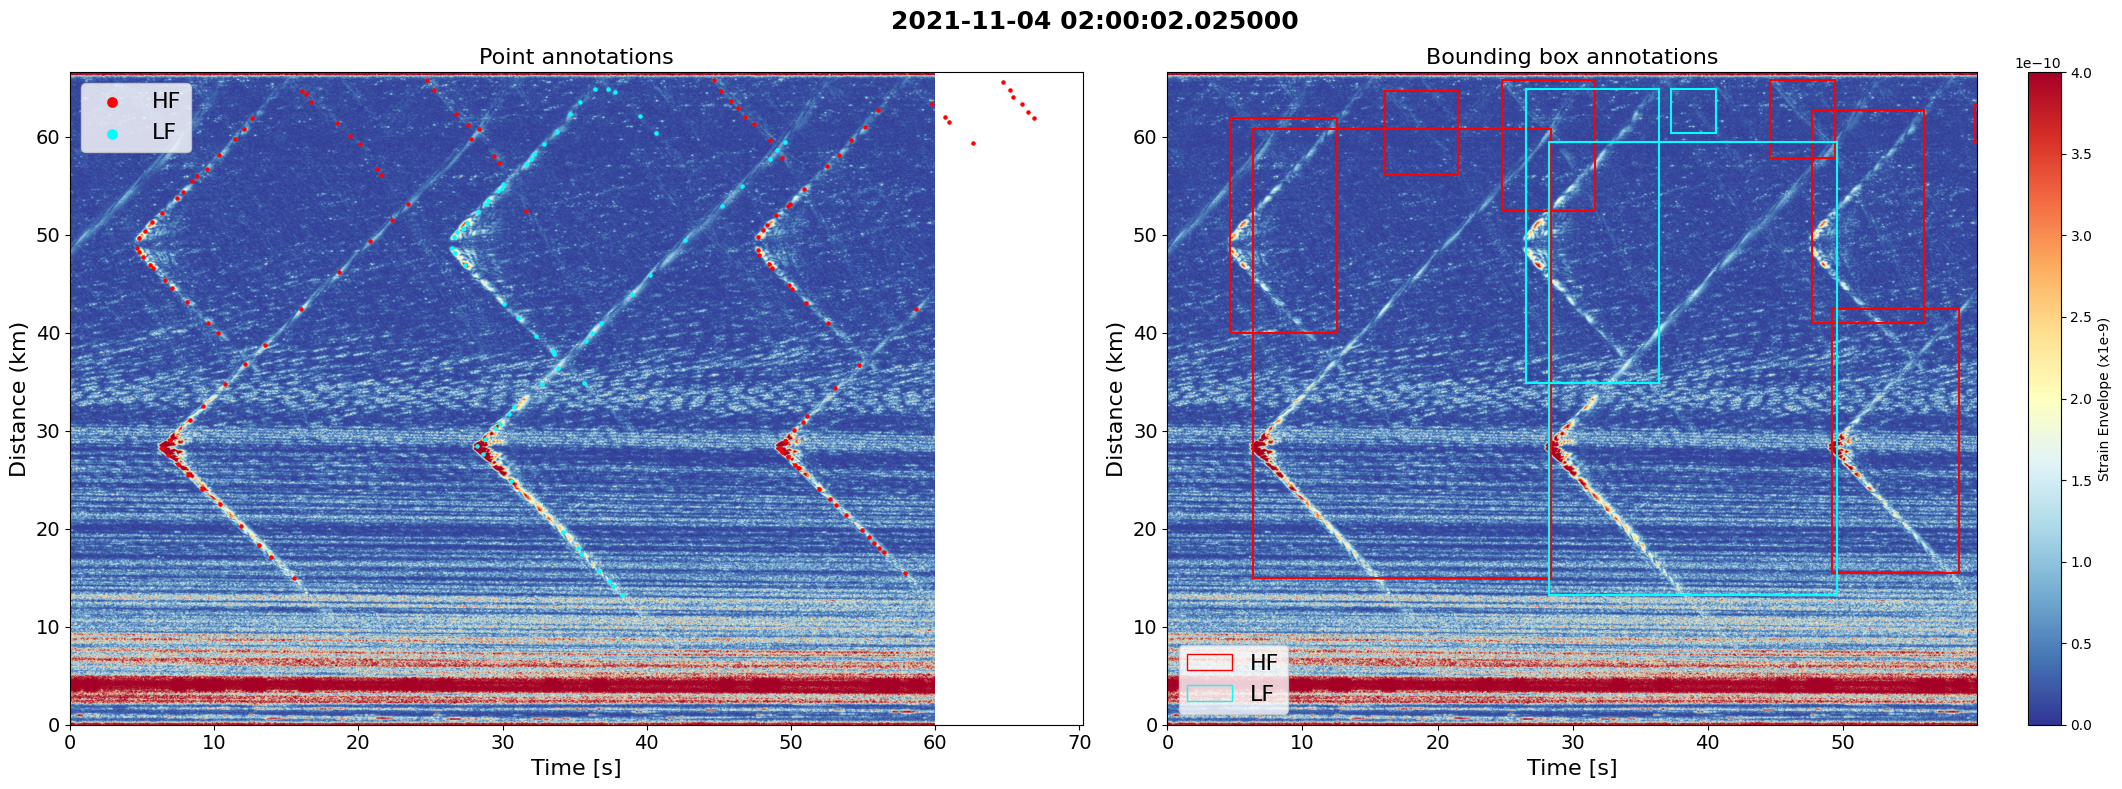

In [41]:
points_csv_path = r"C:\Users\Santi\OneDrive - UPV\TFM - Santiago Campo Jurado\DAS\D4W_bk\Batch1\annotated_calls_north_2021-11-04_02_00_02.csv"
df_points = pd.read_csv(points_csv_path)

FONTSIZE_LABEL = 16
FONTSIZE_TICK  = 14

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle(str(fileBeginTimeUTC), fontsize=18, fontweight='bold')

IMSHOW_KWARGS = dict(
    aspect='auto', origin='lower',
    extent=[time_ds[0], time_ds[-1], dist_ds[0]/1e3, dist_ds[-1]/1e3],
    vmin=0, vmax=0.4e-9, cmap='RdYlBu_r'
)

# ── Subplot 1: Puntos originales ─────────────────────────────────────────
ax1.imshow(envelope_ds, **IMSHOW_KWARGS)
for call_type, grp in df_points.groupby('call_type'):
    ax1.scatter(grp['time'], grp['dist']/1e3, s=5,
                color=COLOR.get(call_type, 'white'), label=call_type)
ax1.set_xlabel('Time [s]', fontsize=FONTSIZE_LABEL)
ax1.set_ylabel('Distance (km)', fontsize=FONTSIZE_LABEL)
ax1.tick_params(labelsize=FONTSIZE_TICK)
ax1.set_title('Point annotations', fontsize=FONTSIZE_LABEL)
ax1.legend(fontsize=FONTSIZE_LABEL, markerscale=3)

# ── Subplot 2: Bounding boxes ────────────────────────────────────────────
im = ax2.imshow(envelope_ds, **IMSHOW_KWARGS)
legend_handles = {}
for _, row in df_bbox.iterrows():
    t0, t1 = row['t0'], row['t1']
    d0, d1 = row['d0'] / 1e3, row['d1'] / 1e3
    label  = row['ID']
    color  = COLOR.get(label, 'white')
    rect   = patches.Rectangle(
        (t0, d0), t1 - t0, d1 - d0,
        linewidth=1.5, edgecolor=color, facecolor='none'
    )
    ax2.add_patch(rect)
    if label not in legend_handles:
        legend_handles[label] = patches.Patch(edgecolor=color, facecolor='none', label=label)
ax2.set_xlabel('Time [s]', fontsize=FONTSIZE_LABEL)
ax2.set_ylabel('Distance (km)', fontsize=FONTSIZE_LABEL)
ax2.tick_params(labelsize=FONTSIZE_TICK)
ax2.set_title('Bounding box annotations', fontsize=FONTSIZE_LABEL)
ax2.legend(handles=list(legend_handles.values()), fontsize=FONTSIZE_LABEL)
plt.colorbar(im, ax=ax2, label='Strain Envelope (x1e-9)')

plt.tight_layout()
plt.show()

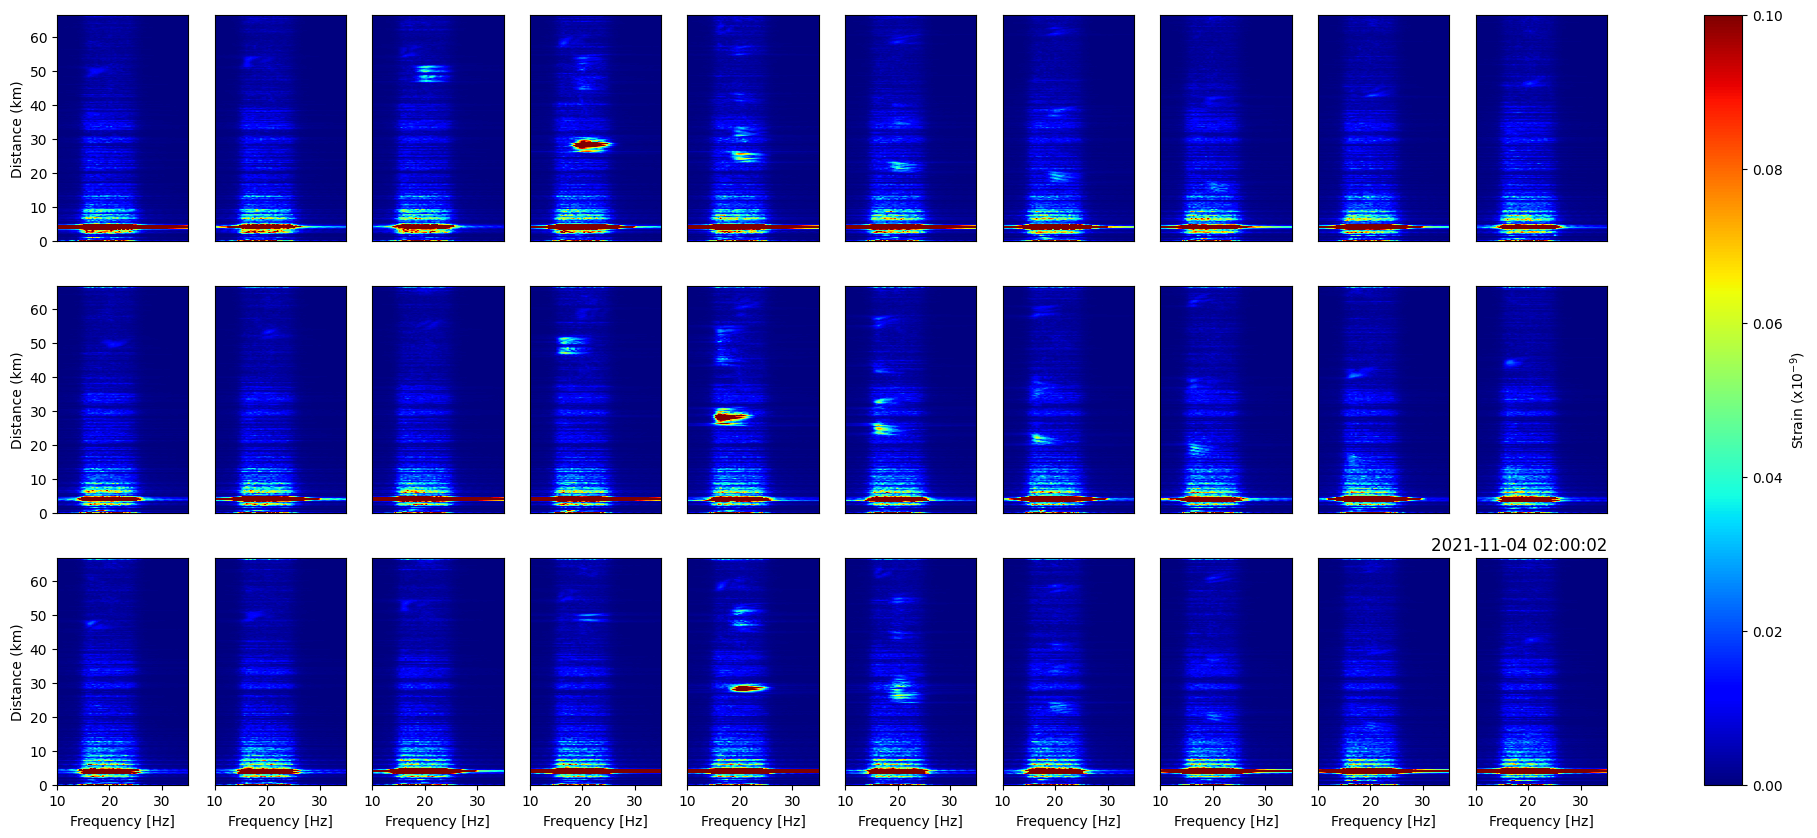

In [16]:
# Spatio-spectral representation (using 2 s segments)
# Frequency x Distance plot

dw.plot.plot_fx(
    trf_fk, dist, fs, title_time_info=fileBeginTimeUTC, win_s=2, nfft=512,  f_min=10, f_max=35, fig_size=(25, 10), 
    v_min = 0, v_max = 0.1)

c:\Users\Santi\anaconda3\envs\whale_synth\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


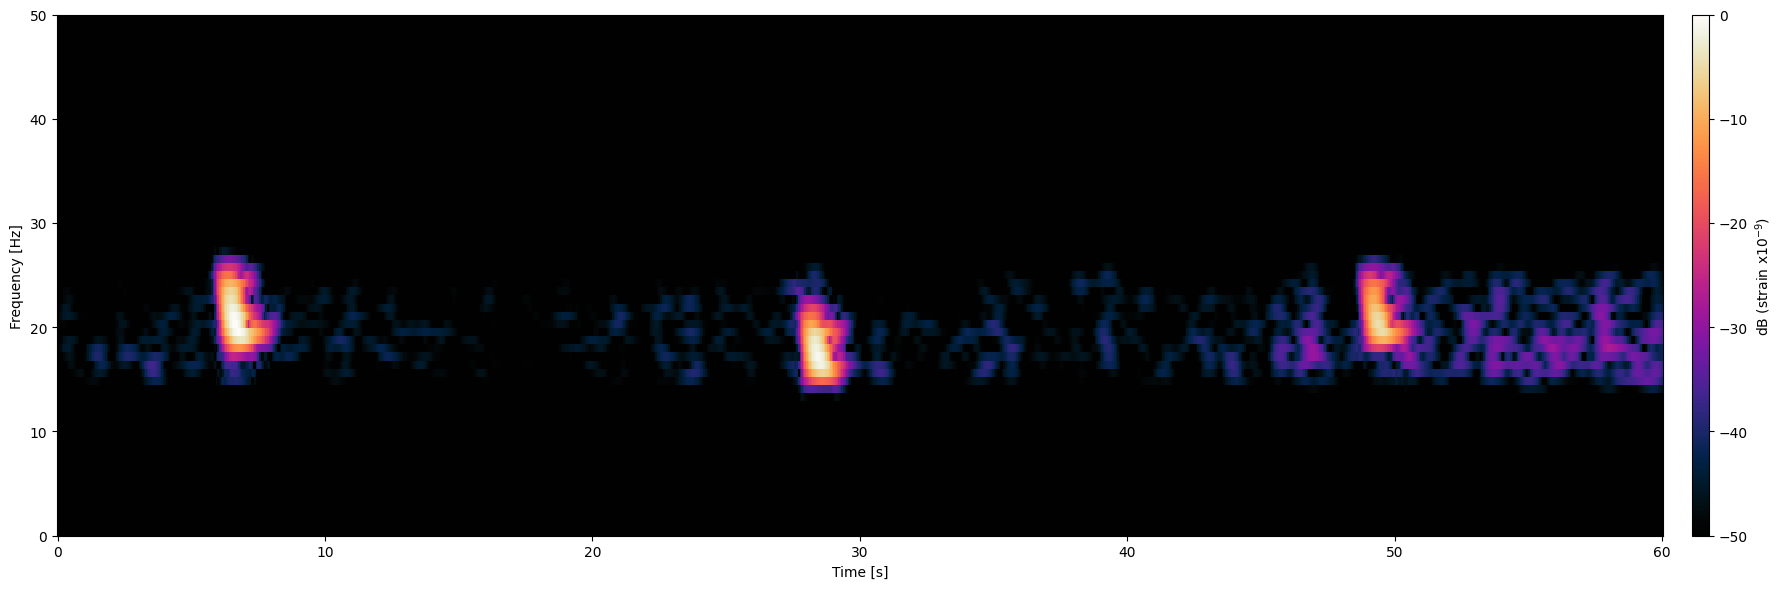

In [17]:
# Select a channel and display audio and its spectrogram

selected_chan = 28000 # (m)
idx = (np.abs(dist - selected_chan)).argmin()

# Spectrogram
p,tt,ff = dw.dsp.get_spectrogram(trf_fk[idx,:], fs, nfft=256, overlap_pct=0.95)
dw.plot.plot_spectrogram(p, tt,ff, f_min = 0, f_max = 50, v_min=-50)

# Audio
display(Audio(data=trf_fk[idx,:], rate=fs*5))